In [1]:
from dask.distributed import Client

client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 11
Total threads: 11,Total memory: 18.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:57729,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:57755,Total threads: 1
Dashboard: http://127.0.0.1:57757/status,Memory: 1.64 GiB
Nanny: tcp://127.0.0.1:57732,


In [3]:
%%time
"""
This cell just opens a netcdf which is sitting in my users object storage on Pawsey.
Mostly intended as a demo that the dataset actually exists, and has the right settings
to be openeed by an anonymous user.
"""

import xarray as xr

url = "s3://virtual-cmorization/output980/iceh.2146-01.nc"

ds = xr.open_dataset(
    url,
    engine="h5netcdf",
    backend_kwargs={
        "storage_options": {
            "anon": True,
            "client_kwargs": {"endpoint_url": "https://projects.pawsey.org.au"},
        }
    },
)

# This is just straight up opening the dataset on Pawsy
# ds['sst_m'].isel(time=0).plot()
varnames = set(k for k in ds.variables.keys())
drop_vars = varnames - {"sst_m","time","nj","ni","ULON","ULAT"}

drop_vars = list(drop_vars)
ds

CPU times: user 769 ms, sys: 177 ms, total: 947 ms
Wall time: 2.16 s


<xarray.Dataset> Size: 3GB
Dimensions:       (time: 1, d2: 2, nj: 2700, ni: 3600, nc: 5)
Coordinates:
  * time          (time) object 8B 2146-02-01 00:00:00
    TLON          (nj, ni) float32 39MB ...
    TLAT          (nj, ni) float32 39MB ...
    ULON          (nj, ni) float32 39MB ...
    ULAT          (nj, ni) float32 39MB ...
    NCAT          (nc) float32 20B ...
Dimensions without coordinates: d2, nj, ni, nc
Data variables: (12/49)
    time_bounds   (time, d2) object 16B ...
    tmask         (nj, ni) float32 39MB ...
    blkmask       (nj, ni) float32 39MB ...
    tarea         (nj, ni) float32 39MB ...
    uarea         (nj, ni) float32 39MB ...
    dxt           (nj, ni) float32 39MB ...
    ...            ...
    fmeltt_ai_m   (time, nj, ni) float32 39MB ...
    opening_m     (time, nj, ni) float32 39MB ...
    aicen_m       (time, nc, nj, ni) float32 194MB ...
    vicen_m       (time, nc, nj, ni) float32 194MB ...
    fmelttn_ai_m  (time, nc, nj, ni) float32 194MB ...
    flatn_ai_m    (time, nc, nj, ni) float32 194MB ...
Attributes:
    title:             sea ice model output for CICE
    contents:          Diagnostic and Prognostic Variables
    source:            Los Alamos Sea Ice Model (CICE) Version 5
    time_period_freq:  month_1
    comment:           All years have exactly 365 days
    comment2:          File written on model date 21460201
    comment3:          seconds elapsed into model date:      0
    conventions:       CF-1.0
    history:           This dataset was created on 2022-10-08 at 10:08
    io_flavor:         io_pio

In [ ]:
import warnings
import os
import xarray as xr
from virtualizarr import open_virtual_dataset, open_virtual_mfdataset
from virtualizarr.parsers import HDFParser
from obstore.store import S3Store
from obspec_utils.registry import ObjectStoreRegistry

import numcodecs.zarr3  # Register the zarr3 codec

from dotenv import load_dotenv

load_dotenv()

access_key_id = os.environ.get("ACCESS_KEY_ID")
secret_access_key = os.environ.get("SECRET_ACCESS_KEY")
endpoint = "https://projects.pawsey.org.au"
bucket = "s3://virtual-cmorization"


# # create anon s3 store
# store = S3Store.from_url(f"{scheme}{path}", endpoint=endpoint, skip_signature=True)

# create s3 store with aws-style credentials
store = S3Store.from_url(
    f"{bucket}",
    endpoint=endpoint,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
)

registry = ObjectStoreRegistry({f"{bucket}": store})

parser = HDFParser()

In [5]:
parser = HDFParser()

vds = open_virtual_dataset(
    url=f"{bucket}/output980/iceh.2146-01.nc",
    parser=parser,
    registry=registry,
)

/Users/u1166368/PawseyVirtualisationTests/.pixi/envs/default/lib/python3.14/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


In [6]:
vds

<xarray.Dataset> Size: 3GB
Dimensions:       (d2: 2, ni: 3600, nj: 2700, nc: 5, nkice: 4, nksnow: 1,
                   nkbio: 9, time: 1, nvertices: 4)
Coordinates: (12/14)
  * d2            (d2) float32 8B 0.0 0.0
  * ni            (ni) float32 14kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
  * nj            (nj) float32 11kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
  * nc            (nc) float32 20B 0.0 0.0 0.0 0.0 0.0
  * nkice         (nkice) float32 16B 0.0 0.0 0.0 0.0
  * nksnow        (nksnow) float32 4B 0.0
    ...            ...
  * nvertices     (nvertices) float32 16B 0.0 0.0 0.0 0.0
    TLON          (nj, ni) float32 39MB ManifestArray<shape=(2700, 3600), dty...
    TLAT          (nj, ni) float32 39MB ManifestArray<shape=(2700, 3600), dty...
    ULON          (nj, ni) float32 39MB ManifestArray<shape=(2700, 3600), dty...
    ULAT          (nj, ni) float32 39MB ManifestArray<shape=(2700, 3600), dty...
    NCAT          (nc) float32 20B ManifestArray<shape=(5,), dtype=float32, c...
Data variables: (12/49)
    time_bounds   (time, d2) float32 8B ManifestArray<shape=(1, 2), dtype=flo...
    tmask         (nj, ni) float32 39MB ManifestArray<shape=(2700, 3600), dty...
    blkmask       (nj, ni) float32 39MB ManifestArray<shape=(2700, 3600), dty...
    tarea         (nj, ni) float32 39MB ManifestArray<shape=(2700, 3600), dty...
    uarea         (nj, ni) float32 39MB ManifestArray<shape=(2700, 3600), dty...
    dxt           (nj, ni) float32 39MB ManifestArray<shape=(2700, 3600), dty...
    ...            ...
    fmeltt_ai_m   (time, nj, ni) float32 39MB ManifestArray<shape=(1, 2700, 3...
    opening_m     (time, nj, ni) float32 39MB ManifestArray<shape=(1, 2700, 3...
    aicen_m       (time, nc, nj, ni) float32 194MB ManifestArray<shape=(1, 5,...
    vicen_m       (time, nc, nj, ni) float32 194MB ManifestArray<shape=(1, 5,...
    fmelttn_ai_m  (time, nc, nj, ni) float32 194MB ManifestArray<shape=(1, 5,...
    flatn_ai_m    (time, nc, nj, ni) float32 194MB ManifestArray<shape=(1, 5,...
Attributes:
    title:             sea ice model output for CICE
    contents:          Diagnostic and Prognostic Variables
    source:            Los Alamos Sea Ice Model (CICE) Version 5
    time_period_freq:  month_1
    comment:           All years have exactly 365 days
    comment2:          File written on model date 21460201
    comment3:          seconds elapsed into model date:      0
    conventions:       CF-1.0
    history:           This dataset was created on 2022-10-08 at 10:08
    io_flavor:         io_pio

We now have proof that we can open that netcdf with virtualizarr. Let's now try opening the entire contents of that bucket as a single virtual dataset.

Following that, we'll try to save it via icechunk

In [7]:
import obstore

flist = []
for batch in obstore.list(store):
    for obj in batch:
        if not obj.get("path","icechunk").startswith("icechunk"):
            flist.append(obj.get("path"))

print(flist[:2])

['output976/iceh.2145-01.nc', 'output976/iceh.2145-02.nc']


In [10]:
urls = [f"{bucket}/{f}" for f in flist]

urls[:3]

['s3://virtual-cmorization/output976/iceh.2145-01.nc',
 's3://virtual-cmorization/output976/iceh.2145-02.nc',
 's3://virtual-cmorization/output976/iceh.2145-03.nc']

In [11]:
combined_vds = open_virtual_mfdataset(
    urls=urls,
    parser=parser,
    registry=registry,
    combine="nested",
    concat_dim="time",
    parallel="dask",
    compat="override",
    coords=["time"],
)
combined_vds

/Users/u1166368/PawseyVirtualisationTests/.pixi/envs/default/lib/python3.14/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/Users/u1166368/PawseyVirtualisationTests/.pixi/envs/default/lib/python3.14/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/Users/u1166368/PawseyVirtualisationTests/.pixi/envs/default/lib/python3.14/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/Users/u1166368/PawseyVirtualisationTests/.pixi/envs/default/lib/python3.14/site-packages/zarr/codecs/numcode

<xarray.Dataset> Size: 105GB
Dimensions:       (time: 42, d2: 2, nj: 2700, ni: 3600, nc: 5, nkice: 4,
                   nksnow: 1, nkbio: 9, nvertices: 4)
Coordinates: (12/14)
  * d2            (d2) float32 8B 0.0 0.0
  * ni            (ni) float32 14kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
  * nj            (nj) float32 11kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
  * nc            (nc) float32 20B 0.0 0.0 0.0 0.0 0.0
  * nkice         (nkice) float32 16B 0.0 0.0 0.0 0.0
  * nksnow        (nksnow) float32 4B 0.0
    ...            ...
  * nvertices     (nvertices) float32 16B 0.0 0.0 0.0 0.0
    TLON          (nj, ni) float32 39MB ManifestArray<shape=(2700, 3600), dty...
    TLAT          (nj, ni) float32 39MB ManifestArray<shape=(2700, 3600), dty...
    ULON          (nj, ni) float32 39MB ManifestArray<shape=(2700, 3600), dty...
    ULAT          (nj, ni) float32 39MB ManifestArray<shape=(2700, 3600), dty...
    NCAT          (nc) float32 20B ManifestArray<shape=(5,), dtype=float32, c...
Data variables: (12/49)
    time_bounds   (time, d2) float32 336B ManifestArray<shape=(42, 2), dtype=...
    tmask         (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    blkmask       (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    tarea         (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    uarea         (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    dxt           (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    ...            ...
    fmeltt_ai_m   (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    opening_m     (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    aicen_m       (time, nc, nj, ni) float32 8GB ManifestArray<shape=(42, 5, ...
    vicen_m       (time, nc, nj, ni) float32 8GB ManifestArray<shape=(42, 5, ...
    fmelttn_ai_m  (time, nc, nj, ni) float32 8GB ManifestArray<shape=(42, 5, ...
    flatn_ai_m    (time, nc, nj, ni) float32 8GB ManifestArray<shape=(42, 5, ...
Attributes:
    title:             sea ice model output for CICE
    contents:          Diagnostic and Prognostic Variables
    source:            Los Alamos Sea Ice Model (CICE) Version 5
    time_period_freq:  month_1
    comment:           All years have exactly 365 days
    comment2:          File written on model date 21450201
    comment3:          seconds elapsed into model date:      0
    conventions:       CF-1.0
    history:           This dataset was created on 2022-10-07 at 10:43
    io_flavor:         io_pio

In [12]:
import numpy as np

# ni and nj have no coordinate values in the source files.
# Assign them as plain numpy arrays so they survive virtualisation.
combined_vds = combined_vds.assign_coords(
    nj=("nj", np.arange(combined_vds.dims["nj"])),
    ni=("ni", np.arange(combined_vds.dims["ni"])),
)
combined_vds


/var/folders/qg/vhg6q9gn4zl01xbg1mfw6jzhxzf1wt/T/ipykernel_51066/1181912939.py:6: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nj=("nj", np.arange(combined_vds.dims["nj"])),
/var/folders/qg/vhg6q9gn4zl01xbg1mfw6jzhxzf1wt/T/ipykernel_51066/1181912939.py:7: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ni=("ni", np.arange(combined_vds.dims["ni"])),


<xarray.Dataset> Size: 105GB
Dimensions:       (time: 42, d2: 2, nj: 2700, ni: 3600, nc: 5, nkice: 4,
                   nksnow: 1, nkbio: 9, nvertices: 4)
Coordinates: (12/14)
  * d2            (d2) float32 8B 0.0 0.0
  * nc            (nc) float32 20B 0.0 0.0 0.0 0.0 0.0
  * nkice         (nkice) float32 16B 0.0 0.0 0.0 0.0
  * nksnow        (nksnow) float32 4B 0.0
  * nkbio         (nkbio) float32 36B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
  * time          (time) object 336B 2145-02-01 00:00:00 ... 2148-07-01 00:00:00
    ...            ...
    TLAT          (nj, ni) float32 39MB ManifestArray<shape=(2700, 3600), dty...
    ULON          (nj, ni) float32 39MB ManifestArray<shape=(2700, 3600), dty...
    ULAT          (nj, ni) float32 39MB ManifestArray<shape=(2700, 3600), dty...
    NCAT          (nc) float32 20B ManifestArray<shape=(5,), dtype=float32, c...
  * nj            (nj) int64 22kB 0 1 2 3 4 5 ... 2694 2695 2696 2697 2698 2699
  * ni            (ni) int64 29kB 0 1 2 3 4 5 ... 3594 3595 3596 3597 3598 3599
Data variables: (12/49)
    time_bounds   (time, d2) float32 336B ManifestArray<shape=(42, 2), dtype=...
    tmask         (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    blkmask       (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    tarea         (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    uarea         (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    dxt           (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    ...            ...
    fmeltt_ai_m   (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    opening_m     (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    aicen_m       (time, nc, nj, ni) float32 8GB ManifestArray<shape=(42, 5, ...
    vicen_m       (time, nc, nj, ni) float32 8GB ManifestArray<shape=(42, 5, ...
    fmelttn_ai_m  (time, nc, nj, ni) float32 8GB ManifestArray<shape=(42, 5, ...
    flatn_ai_m    (time, nc, nj, ni) float32 8GB ManifestArray<shape=(42, 5, ...
Attributes:
    title:             sea ice model output for CICE
    contents:          Diagnostic and Prognostic Variables
    source:            Los Alamos Sea Ice Model (CICE) Version 5
    time_period_freq:  month_1
    comment:           All years have exactly 365 days
    comment2:          File written on model date 21450201
    comment3:          seconds elapsed into model date:      0
    conventions:       CF-1.0
    history:           This dataset was created on 2022-10-07 at 10:43
    io_flavor:         io_pio

In [ ]:
# Copied from `~/scratch/virtualizarr/test_nb.ipynb`
# Just using to save the combined virtual dataset as a zarr via icechunk, so we
# don't have to fetch it from pawsey to rebuild it there if something crashes
import xarray as xr
import icechunk
from pathlib import Path

# Create a new repository instance with virtual chunk container permissions for reading
config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=f"{bucket}/",
        store=icechunk.s3_store(
            endpoint_url=endpoint,              # "https://projects.pawsey.org.au"
            s3_compatible=True,
            force_path_style=True,
        )
    ),
)

credentials = icechunk.containers_credentials(
    { 
        bucket: icechunk.s3_credentials(
            access_key_id=access_key_id, 
            secret_access_key=secret_access_key,
        )
    }
)

# Open the repository with the config that includes virtual chunk permissions
storage = icechunk.local_filesystem_storage("/Users/u1166368/PawseyVirtualisationTests/pawsey/virtual-cmorization")
repo = icechunk.Repository.create(storage, config, authorize_virtual_chunk_access=credentials)

# Write your virtual dataset to the repository
write_session = repo.writable_session("main")
combined_vds.vz.to_icechunk(write_session.store)
write_session.commit("Write Pawsey virtual-cmorization virtual dataset to local zarr store for testing")

  2026-03-30T07:09:51.940729Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:81



'DDX9CXG5HMB3GK5DVGX0'

In [19]:
combined_vds

<xarray.Dataset> Size: 105GB
Dimensions:       (time: 42, d2: 2, nj: 2700, ni: 3600, nc: 5, nkice: 4,
                   nksnow: 1, nkbio: 9, nvertices: 4)
Coordinates: (12/14)
  * d2            (d2) float32 8B 0.0 0.0
  * nc            (nc) float32 20B 0.0 0.0 0.0 0.0 0.0
  * nkice         (nkice) float32 16B 0.0 0.0 0.0 0.0
  * nksnow        (nksnow) float32 4B 0.0
  * nkbio         (nkbio) float32 36B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
  * time          (time) object 336B 2145-02-01 00:00:00 ... 2148-07-01 00:00:00
    ...            ...
    TLAT          (nj, ni) float32 39MB ManifestArray<shape=(2700, 3600), dty...
    ULON          (nj, ni) float32 39MB ManifestArray<shape=(2700, 3600), dty...
    ULAT          (nj, ni) float32 39MB ManifestArray<shape=(2700, 3600), dty...
    NCAT          (nc) float32 20B ManifestArray<shape=(5,), dtype=float32, c...
  * nj            (nj) int64 22kB 0 1 2 3 4 5 ... 2694 2695 2696 2697 2698 2699
  * ni            (ni) int64 29kB 0 1 2 3 4 5 ... 3594 3595 3596 3597 3598 3599
Data variables: (12/49)
    time_bounds   (time, d2) float32 336B ManifestArray<shape=(42, 2), dtype=...
    tmask         (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    blkmask       (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    tarea         (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    uarea         (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    dxt           (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    ...            ...
    fmeltt_ai_m   (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    opening_m     (time, nj, ni) float32 2GB ManifestArray<shape=(42, 2700, 3...
    aicen_m       (time, nc, nj, ni) float32 8GB ManifestArray<shape=(42, 5, ...
    vicen_m       (time, nc, nj, ni) float32 8GB ManifestArray<shape=(42, 5, ...
    fmelttn_ai_m  (time, nc, nj, ni) float32 8GB ManifestArray<shape=(42, 5, ...
    flatn_ai_m    (time, nc, nj, ni) float32 8GB ManifestArray<shape=(42, 5, ...
Attributes:
    title:             sea ice model output for CICE
    contents:          Diagnostic and Prognostic Variables
    source:            Los Alamos Sea Ice Model (CICE) Version 5
    time_period_freq:  month_1
    comment:           All years have exactly 365 days
    comment2:          File written on model date 21450201
    comment3:          seconds elapsed into model date:      0
    conventions:       CF-1.0
    history:           This dataset was created on 2022-10-07 at 10:43
    io_flavor:         io_pio

In [31]:
renamed_ds = combined_vds.rename({
    "sst_m": "sea_surface_temperature",
    "sss_m" : "sea_surface_salinity",
})

In [ ]:
# Step one: very simple virtualisation: rename a variable

### Works locally - so write to pawsey. First the 'uncmorized' version, then the 'cmorized' version.

In [25]:
""" 
UNCMORIZED
"""
# Now put the virtual dataset in the bucket alongside the netcdf files
import xarray as xr
import icechunk
from pathlib import Path

# Create a new repository instance with virtual chunk container permissions for reading
config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=f"{bucket}/",
        store=icechunk.s3_store(
            endpoint_url=endpoint,              # "https://projects.pawsey.org.au"
            s3_compatible=True,
            force_path_style=True,
        )
    ),
)

credentials = icechunk.containers_credentials(
    { 
        bucket: icechunk.s3_credentials(
            access_key_id=access_key_id, 
            secret_access_key=secret_access_key,
        )
    }
)

# Open the repository with the config that includes virtual chunk permissions
storage = icechunk.s3_storage(
    bucket='virtual-cmorization',
    prefix='uncmorized',
    endpoint_url=endpoint,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    force_path_style=True,
)

repo = icechunk.Repository.create(
    storage,
    config,
    authorize_virtual_chunk_access=credentials
)

# Write your virtual dataset to the repository
write_session = repo.writable_session("main")
combined_vds.vz.to_icechunk(write_session.store)
write_session.commit("Write Pawsey virtual-cmorisation dataset to acacia zarr store for testing")

  2026-03-30T08:48:20.764128Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /Users/runner/miniforge3/conda-bld/icechunk_1772465843790/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



'P8KC5QXNZCNCK05XMGG0'

In [26]:
""" 
CMORIZED
"""
# Now put the virtual dataset in the bucket alongside the netcdf files
import xarray as xr
import icechunk
from pathlib import Path

# Create a new repository instance with virtual chunk container permissions for reading
config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=f"{bucket}/",
        store=icechunk.s3_store(
            endpoint_url=endpoint,              # "https://projects.pawsey.org.au"
            s3_compatible=True,
            force_path_style=True,
        )
    ),
)

credentials = icechunk.containers_credentials(
    { 
        bucket: icechunk.s3_credentials(
            access_key_id=access_key_id, 
            secret_access_key=secret_access_key,
        )
    }
)

# Open the repository with the config that includes virtual chunk permissions
storage = icechunk.s3_storage(
    bucket='virtual-cmorization',
    prefix='cmorized-names-only',
    endpoint_url=endpoint,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    force_path_style=True,
)

repo = icechunk.Repository.create(
    storage,
    config,
    authorize_virtual_chunk_access=credentials
)

# Write your virtual dataset to the repository
write_session = repo.writable_session("main")
renamed_ds.vz.to_icechunk(write_session.store)
write_session.commit("Write Pawsey virtual-cmorisation dataset to acacia zarr store for testing - renamed variables only")

  2026-03-30T08:49:08.989322Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /Users/runner/miniforge3/conda-bld/icechunk_1772465843790/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



'50NGW8ZFGF5NA4PGHBSG'

In [32]:
renamed_ds.attrs['Has_Charles_Turner_messed_with_this_dataset?'] = "Yes, he has renamed the variables to be more descriptive, but otherwise not messed with it at all"
renamed_ds.sea_surface_salinity.attrs['Has_Charles_Turner_messed_with_this_variable?'] = "No, I have not changed anything about this variable except its name... and now it's metadata"
renamed_ds.sea_surface_temperature.attrs['Has_Charles_Turner_messed_with_this_variable?'] = "No, I have not changed anything about this variable except its name... and now it's metadata"

renamed_ds

<xarray.Dataset> Size: 105GB
Dimensions:                  (time: 42, d2: 2, nj: 2700, ni: 3600, nc: 5,
                              nkice: 4, nksnow: 1, nkbio: 9, nvertices: 4)
Coordinates: (12/14)
  * d2                       (d2) float32 8B 0.0 0.0
  * nc                       (nc) float32 20B 0.0 0.0 0.0 0.0 0.0
  * nkice                    (nkice) float32 16B 0.0 0.0 0.0 0.0
  * nksnow                   (nksnow) float32 4B 0.0
  * nkbio                    (nkbio) float32 36B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
  * time                     (time) object 336B 2145-02-01 00:00:00 ... 2148-...
    ...                       ...
    TLAT                     (nj, ni) float32 39MB ManifestArray<shape=(2700,...
    ULON                     (nj, ni) float32 39MB ManifestArray<shape=(2700,...
    ULAT                     (nj, ni) float32 39MB ManifestArray<shape=(2700,...
    NCAT                     (nc) float32 20B ManifestArray<shape=(5,), dtype...
  * nj                       (nj) int64 22kB 0 1 2 3 4 ... 2696 2697 2698 2699
  * ni                       (ni) int64 29kB 0 1 2 3 4 ... 3596 3597 3598 3599
Data variables: (12/49)
    time_bounds              (time, d2) float32 336B ManifestArray<shape=(42,...
    tmask                    (time, nj, ni) float32 2GB ManifestArray<shape=(...
    blkmask                  (time, nj, ni) float32 2GB ManifestArray<shape=(...
    tarea                    (time, nj, ni) float32 2GB ManifestArray<shape=(...
    uarea                    (time, nj, ni) float32 2GB ManifestArray<shape=(...
    dxt                      (time, nj, ni) float32 2GB ManifestArray<shape=(...
    ...                       ...
    fmeltt_ai_m              (time, nj, ni) float32 2GB ManifestArray<shape=(...
    opening_m                (time, nj, ni) float32 2GB ManifestArray<shape=(...
    aicen_m                  (time, nc, nj, ni) float32 8GB ManifestArray<sha...
    vicen_m                  (time, nc, nj, ni) float32 8GB ManifestArray<sha...
    fmelttn_ai_m             (time, nc, nj, ni) float32 8GB ManifestArray<sha...
    flatn_ai_m               (time, nc, nj, ni) float32 8GB ManifestArray<sha...
Attributes:
    title:                                         sea ice model output for CICE
    contents:                                      Diagnostic and Prognostic ...
    source:                                        Los Alamos Sea Ice Model (...
    time_period_freq:                              month_1
    comment:                                       All years have exactly 365...
    comment2:                                      File written on model date...
    comment3:                                      seconds elapsed into model...
    conventions:                                   CF-1.0
    history:                                       This dataset was created o...
    io_flavor:                                     io_pio
    Has_Charles_Turner_messed_with_this_dataset?:  Yes, he has renamed the va...

In [ ]:
""" 
CMORIZED
"""
# Now put the virtual dataset in the bucket alongside the netcdf files
import xarray as xr
import icechunk
from pathlib import Path

# Create a new repository instance with virtual chunk container permissions for reading
config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=f"{bucket}/",
        store=icechunk.s3_store(
            endpoint_url=endpoint,              # "https://projects.pawsey.org.au"
            s3_compatible=True,
            force_path_style=True,
        )
    ),
)

credentials = icechunk.containers_credentials(
    { 
        bucket: icechunk.s3_credentials(
            access_key_id=access_key_id, 
            secret_access_key=secret_access_key,
        )
    }
)

# Open the repository with the config that includes virtual chunk permissions
storage = icechunk.s3_storage(
    bucket='virtual-cmorization',
    prefix='cmorized-names-and-attrs',
    endpoint_url=endpoint,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    force_path_style=True,
)

repo = icechunk.Repository.create(
    storage,
    config,
    authorize_virtual_chunk_access=credentials
)

# Write your virtual dataset to the repository
write_session = repo.writable_session("main")
renamed_ds.vz.to_icechunk(write_session.store)
# I forgot to change the commit message before writing... whoops
write_session.commit("Write Pawsey virtual-cmorisation dataset to acacia zarr store for testing - renamed variables and attributes")

  2026-03-30T08:52:09.961842Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /Users/runner/miniforge3/conda-bld/icechunk_1772465843790/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



'7ZEGRJV6ZRFS6YAVF4AG'

In [34]:
renamed_ds['sea_surface_temperature_K'] = renamed_ds.sea_surface_temperature + 273.15

TypeError: unsupported operand type(s) for +: 'ManifestArray' and 'float'

In [ ]:
# And write to a local kerchunk container using json
combined_vds.vz.to_kerchunk(
    filepath="//Users/u1166368/scratch/virtualizarr/pawsey/ref-virtual-cmorization.json",
    format='json',
)

In [ ]:
import fsspec

refs = combined_vds.vz.to_kerchunk(format='dict')

with fsspec.open(
    "s3://virtual-cmorization/reference.json",
    "wb",
    client_kwargs={"endpoint_url": endpoint},
    key=access_key_id,
    secret=secret_access_key,
) as f:
    import json
    f.write(json.dumps(refs).encode("utf-8"))

In [ ]:
# And try as parquet too
combined_vds.vz.to_kerchunk(
    filepath="file:///Users/u1166368/scratch/virtualizarr/pawsey/ref-virtual-cmorization.pq",
    format='parquet',
    record_size=50_000
)

In [ ]:
from dask.distributed import Client

client = Client(threads_per_worker=1)
client

In [40]:
import icechunk
from dotenv import load_dotenv
import os
import xarray as xr
load_dotenv()

access_key_id = os.environ.get("ACCESS_KEY_ID")
secret_access_key = os.environ.get("SECRET_ACCESS_KEY")

endpoint = "https://projects.pawsey.org.au"
bucket = "s3://virtual-cmorization"

storage = icechunk.s3_storage(
    bucket='virtual-cmorization',
    prefix='uncmorized',
    endpoint_url=endpoint,
    anonymous=True,
    force_path_style=True,
)

credentials = icechunk.containers_credentials(
    { 
        bucket: icechunk.s3_credentials(
            access_key_id=access_key_id, 
            secret_access_key=secret_access_key,
        )
    }
)

repo = icechunk.Repository.open(storage=storage, config=None, authorize_virtual_chunk_access=credentials)

session = repo.readonly_session("main")
ds = xr.open_zarr(session.store, consolidated=False)
'sea_surface_temperature' in ds.variables

  2026-03-30T09:01:12.628533Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /Users/runner/miniforge3/conda-bld/icechunk_1772465843790/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



/Users/u1166368/PawseyVirtualisationTests/.pixi/envs/default/lib/python3.14/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


  2026-03-30T09:01:13.158327Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: io error: client error (Connect): tcp connect error: Host is down (os error 64) (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Io, source: hyper_util::client::legacy::Error(Connect, ConnectError("tcp connect error", 169.254.169.254:80, Os { code: 64, kind: Uncategorized, message: "Host is down" })), connection: Unknown } }) }))
    at /Users/runner/miniforge3/conda-bld/icechunk_1772465843790/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



False

In [42]:
import icechunk
from dotenv import load_dotenv
import os
import xarray as xr
load_dotenv()

access_key_id = os.environ.get("ACCESS_KEY_ID")
secret_access_key = os.environ.get("SECRET_ACCESS_KEY")

endpoint = "https://projects.pawsey.org.au"
bucket = "s3://virtual-cmorization"

storage = icechunk.s3_storage(
    bucket='virtual-cmorization',
    prefix='cmorized-names-only',
    endpoint_url=endpoint,
    anonymous=True,
    force_path_style=True,
)

credentials = icechunk.containers_credentials(
    { 
        bucket: icechunk.s3_credentials(
            access_key_id=access_key_id, 
            secret_access_key=secret_access_key,
        )
    }
)

repo = icechunk.Repository.open(storage=storage, config=None, authorize_virtual_chunk_access=credentials)

session = repo.readonly_session("main")
ds = xr.open_zarr(session.store, consolidated=False)
'sea_surface_temperature' in ds.variables
ds.attrs

  2026-03-30T09:01:51.893047Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /Users/runner/miniforge3/conda-bld/icechunk_1772465843790/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



/Users/u1166368/PawseyVirtualisationTests/.pixi/envs/default/lib/python3.14/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


  2026-03-30T09:01:52.381818Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: io error: client error (Connect): tcp connect error: Host is down (os error 64) (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Io, source: hyper_util::client::legacy::Error(Connect, ConnectError("tcp connect error", 169.254.169.254:80, Os { code: 64, kind: Uncategorized, message: "Host is down" })), connection: Unknown } }) }))
    at /Users/runner/miniforge3/conda-bld/icechunk_1772465843790/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



{'title': 'sea ice model output for CICE',
 'contents': 'Diagnostic and Prognostic Variables',
 'source': 'Los Alamos Sea Ice Model (CICE) Version 5',
 'time_period_freq': 'month_1',
 'comment': 'All years have exactly 365 days',
 'comment2': 'File written on model date 21450201',
 'comment3': 'seconds elapsed into model date:      0',
 'conventions': 'CF-1.0',
 'history': 'This dataset was created on 2022-10-07 at 10:43',
 'io_flavor': 'io_pio'}

In [43]:
import icechunk
from dotenv import load_dotenv
import os
import xarray as xr
load_dotenv()

access_key_id = os.environ.get("ACCESS_KEY_ID")
secret_access_key = os.environ.get("SECRET_ACCESS_KEY")

endpoint = "https://projects.pawsey.org.au"
bucket = "s3://virtual-cmorization"

storage = icechunk.s3_storage(
    bucket='virtual-cmorization',
    prefix='cmorized-names-and_attrs',
    endpoint_url=endpoint,
    anonymous=True,
    force_path_style=True,
)

credentials = icechunk.containers_credentials(
    { 
        bucket: icechunk.s3_credentials(
            access_key_id=access_key_id, 
            secret_access_key=secret_access_key,
        )
    }
)

repo = icechunk.Repository.open(storage=storage, config=None, authorize_virtual_chunk_access=credentials)

session = repo.readonly_session("main")
ds = xr.open_zarr(session.store, consolidated=False)
'sea_surface_temperature' in ds.variables
ds.attrs

  2026-03-30T09:02:17.331408Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /Users/runner/miniforge3/conda-bld/icechunk_1772465843790/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



/Users/u1166368/PawseyVirtualisationTests/.pixi/envs/default/lib/python3.14/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


  2026-03-30T09:02:19.196170Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /Users/runner/miniforge3/conda-bld/icechunk_1772465843790/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



{'title': 'sea ice model output for CICE',
 'contents': 'Diagnostic and Prognostic Variables',
 'source': 'Los Alamos Sea Ice Model (CICE) Version 5',
 'time_period_freq': 'month_1',
 'comment': 'All years have exactly 365 days',
 'comment2': 'File written on model date 21450201',
 'comment3': 'seconds elapsed into model date:      0',
 'conventions': 'CF-1.0',
 'history': 'This dataset was created on 2022-10-07 at 10:43',
 'io_flavor': 'io_pio',
 'Has_Charles_Turner_messed_with_this_dataset?': 'Yes, he has renamed the variables to be more descriptive, but otherwise not messed with it at all'}

In [ ]:
xr.open_zarr(session.store, consolidated=False)['sst_m'].isel(time=0).sel(ni=slice(0,1000), nj=slice(500,1250)).plot()

In [ ]:
import matplotlib.pyplot as plt
import xarray as xr

xr.open_zarr(session.store, consolidated=False)['sst_m'].isel(time=0).sel(ni=slice(2600,3000), nj=slice(1600,2000)).plot()

In [ ]:
import xarray as xr

url = "s3://virtual-cmorization/reference.json"

ds = xr.open_dataset(
    url,
    backend_kwargs={
        "storage_options": {
            "anon": True,
            "client_kwargs": {"endpoint_url": "https://projects.pawsey.org.au"},
        }
    },
)
ds['sst_m'].isel(time=0, ni=slice(400,1350), nj=slice(0,1200)).plot()

PermissionError: Forbidden

In [ ]:
import xarray as xr
from dask.distributed import Client

client = Client(threads_per_worker=1)
client

url = "/Users/u1166368/scratch/virtualizarr/pawsey/ref-virtual-cmorization.json"

# This is a bit of a mouthful...
ds = xr.open_dataset(
    "reference://", engine="zarr",
    backend_kwargs={
        "storage_options": {
            "fo": url,
            "remote_protocol": "s3",
            "remote_options": {
                "asynchronous": True, 
                "anon": True,
                "endpoint_url": "https://projects.pawsey.org.au",
                }
        },
        "consolidated": False
    }, 
)
ds

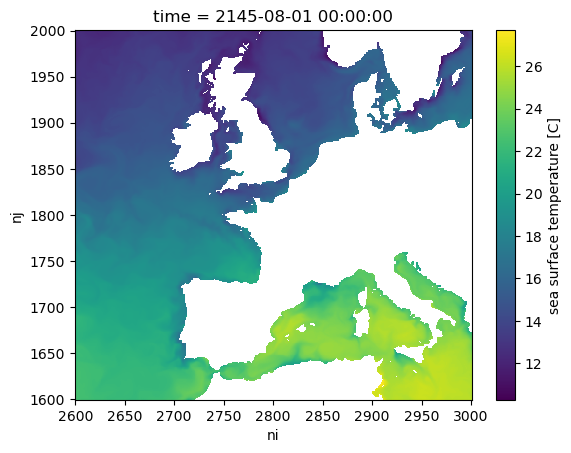

In [3]:
ds['sst_m'].isel(time=0).sel(ni=slice(2600,3000), nj=slice(1600,2000)).plot()

In [ ]:
# Takes about 0.5-1S to stream and plot this lovely map of THE WORLD ACCORDING TO 
# THE ENGLISH (I chose this because of it's relatively small area)

In [ ]:
client.close()